# Predicting Failure Within a Future Window with Nori

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Synthefy/synthefy-nori/blob/main/examples/notebooks/nori-failure-horizon.ipynb)

Turn complete machine histories into one row per engine, use Nori to produce a continuous failure score, and compare it with a 500-configuration XGBoost search. A separate alert threshold converts the score into an operational zero-or-one decision.

This is the runnable companion to [Predicting Failure Within a Future Window with Nori](https://synthefy.com/blog/nori-predictive-maintenance). It uses NASA's public FD001 turbofan benchmark: 100 run-to-failure engines for context and the separate official 100-engine test fleet for evaluation.


## Setup

Run the next cell in a fresh Google Colab runtime. It installs Nori and every Python dependency used by this notebook. The following cell downloads NASA FD001 automatically, and Nori downloads its public checkpoint automatically on the first prediction. No repository clone or local data files are required.

When working from a local clone instead, use `uv sync --extra train --extra eval` and skip the install cell.

Dataset: [NASA Turbofan Engine Degradation Simulation](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/)


In [1]:
# Required in a fresh Google Colab runtime.
%pip install -q "synthefy-nori[eval]" xgboost joblib ipywidgets


Note: you may need to restart the kernel to use updated packages.


In [2]:
import io
import math
import os
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, ParameterSampler, StratifiedGroupKFold
from synthefy_nori import NoriRegressor
from xgboost import XGBClassifier, XGBRegressor

TEST_SEED = 42
RUL_CAP = 125
HORIZON = 30
EPS = 1e-9
RECENT_SHORT_WINDOW = 5
RECENT_LONG_WINDOW = 20
XGB_SEARCH_CONFIGS = int(os.environ.get("XGB_SEARCH_CONFIGS", "500"))
XGB_JOBS = int(os.environ.get("XGB_JOBS", str(min(8, os.cpu_count() or 1))))

COLUMNS = [
    "unit", "cycle", "op_1", "op_2", "op_3",
    *[f"sensor_{index}" for index in range(1, 22)],
]
SENSORS = [
    "sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_8",
    "sensor_9", "sensor_11", "sensor_12", "sensor_13", "sensor_14",
    "sensor_15", "sensor_17", "sensor_20", "sensor_21",
]

DATA_URL = (
    "https://phm-datasets.s3.amazonaws.com/NASA/"
    "6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip"
)


def prepare_fd001() -> Path:
    """Return the FD001 directory, downloading NASA's archive when needed."""
    configured = os.environ.get("CMAPSS_DATA_DIR")
    if configured:
        data_dir = Path(configured).expanduser()
        if (data_dir / "train_FD001.txt").exists():
            return data_dir
        raise FileNotFoundError(f"CMAPSS_DATA_DIR does not contain FD001 files: {data_dir}")

    cache = Path("data/nasa-cmapss")
    existing = next(cache.rglob("train_FD001.txt"), None) if cache.exists() else None
    if existing is not None:
        return existing.parent

    cache.mkdir(parents=True, exist_ok=True)
    archive = cache / "turbofan-engine-degradation.zip"
    request = urllib.request.Request(DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
    archive.write_bytes(urllib.request.urlopen(request, timeout=120).read())
    with zipfile.ZipFile(archive) as bundle:
        bundle.extractall(cache)

    # Some mirrors wrap CMAPSSData.zip inside the outer archive.
    for nested_archive in cache.rglob("*.zip"):
        if nested_archive == archive:
            continue
        nested_dir = nested_archive.with_suffix("")
        nested_dir.mkdir(exist_ok=True)
        with zipfile.ZipFile(nested_archive) as bundle:
            bundle.extractall(nested_dir)

    extracted = next(cache.rglob("train_FD001.txt"), None)
    if extracted is None:
        raise FileNotFoundError("NASA archive did not contain train_FD001.txt")
    return extracted.parent


DATA_DIR = prepare_fd001()
print("NASA FD001 data is ready.")

NASA FD001 data is ready.


## Build one row per machine

### The 30-cycle horizon

Let `t` be the cycle when we score an engine and `T` be its eventual failure cycle. Every feature is calculated from the engine history through `t` only; cycles after `t` never enter the feature table. The binary target is:

```python
failure_within_30 = int((T - t) <= 30)
```

This is a **within-the-next-30-cycles** task, not an exactly-30-cycles-before-failure task. A snapshot at `t = T - 30` is on the positive boundary, and snapshots closer to failure are positive too. Negative snapshots have more than 30 cycles remaining. This matches deployment, where the model may be scored repeatedly and must use only the information available at each scoring cycle.

Each row combines three kinds of information available at the prediction point:

1. **Operational context** — machine age and operating settings.
2. **Current and recent state** — current readings plus five- and twenty-cycle summaries.
3. **Evolution through time** — relative level, slope, monotonicity, persistence, and volatility.

The functions below calculate the complete 172-feature benchmark table. These are illustrative features; domain knowledge can suggest additional ones for a real deployment.

In [3]:
def read_trajectory(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, sep=r"\s+", header=None, names=COLUMNS)
    if frame.shape[1] != len(COLUMNS):
        raise ValueError(f"Expected {len(COLUMNS)} columns in {path}, found {frame.shape[1]}")
    return frame

def _rolling_slope(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    if len(values) < 3:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x -= x.mean()
    return float(np.dot(x, values - values.mean()) / (np.dot(x, x) + EPS))

def _spearman_time(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    if len(values) < 4 or np.nanstd(values) < EPS:
        return 0.0
    ranks = pd.Series(values).rank(method="average").to_numpy(dtype=float)
    return float(np.corrcoef(np.arange(len(values), dtype=float), ranks)[0, 1])

def _max_recency(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return 1.0
    return float(np.nanargmax(np.abs(values))) / float(len(values) - 1)

def _longest_run(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return 0.0
    best = run = 0
    for active in np.abs(values) > 2.0:
        run = run + 1 if active else 0
        best = max(best, run)
    return float(best) / float(len(values))

def _scale(values: np.ndarray) -> tuple[float, float]:
    median = float(np.median(values))
    mad = 1.4826 * float(np.median(np.abs(values - median)))
    if mad < EPS:
        mad = float(np.std(values))
    return median, max(mad, EPS)

def _snapshot_row(history: pd.DataFrame, feature_set: str) -> dict[str, float]:
    """Collapse one machine's observed history into one fixed-length row."""
    history = history.sort_values("cycle")
    latest = history.iloc[-1]
    row: dict[str, float] = {
        "unit": float(latest["unit"]),
        "cycle": float(latest["cycle"]),
        "op_1": float(latest["op_1"]),
        "op_2": float(latest["op_2"]),
        "op_3": float(latest["op_3"]),
    }
    for sensor in SENSORS:
        values = history[sensor].to_numpy(dtype=float)
        if feature_set == "basic":
            row[sensor] = float(values[-1])
            row[f"{sensor}__mean_5"] = float(np.mean(values[-5:]))
            row[f"{sensor}__delta_5"] = float(values[-1] - values[max(0, len(values) - 6)])
            continue

        median, scale = _scale(values)
        standardized = np.clip((values - median) / scale, -12.0, 12.0)
        early = values[: max(5, len(values) // 3)]
        early_median, early_scale = _scale(early)
        early_z = np.clip((values - early_median) / early_scale, -12.0, 12.0)
        recent = values[-min(20, len(values)):]
        recent_std = float(np.std(recent))
        row[f"{sensor}__current"] = float(values[-1])
        row[f"{sensor}__last_vs_history"] = float(standardized[-1])
        row[f"{sensor}__slope"] = float(np.clip(_rolling_slope(values) / scale, -8.0, 8.0))
        row[f"{sensor}__spearman_t"] = _spearman_time(values)
        row[f"{sensor}__max_recency"] = _max_recency(standardized)
        row[f"{sensor}__longest_run"] = _longest_run(early_z)
        row[f"{sensor}__volatility_shift"] = float(np.log1p(min(recent_std / early_scale, 20.0)))

        if feature_set == "recent_trajectory":
            short_size = min(RECENT_SHORT_WINDOW, len(values))
            long_size = min(RECENT_LONG_WINDOW, len(values))
            recent_short_z = standardized[-short_size:]
            recent_long = values[-long_size:]
            recent_long_early_z = early_z[-long_size:]
            prior_end = len(standardized) - short_size
            prior_start = max(0, prior_end - short_size)
            prior_short_z = standardized[prior_start:prior_end]
            prior_mean = float(np.mean(prior_short_z)) if len(prior_short_z) else float(np.mean(recent_short_z))

            row[f"{sensor}__recent_mean_5_vs_history"] = float(np.mean(recent_short_z))
            row[f"{sensor}__recent_mean_shift_5"] = float(np.clip(np.mean(recent_short_z) - prior_mean, -12.0, 12.0))
            row[f"{sensor}__recent_slope_20"] = float(np.clip(_rolling_slope(recent_long) / scale, -8.0, 8.0))
            row[f"{sensor}__recent_range_20"] = float(np.clip(np.ptp(recent_long) / scale, 0.0, 24.0))
            row[f"{sensor}__recent_outlier_share_20"] = float(np.mean(np.abs(recent_long_early_z) > 2.0))
    return row

def _training_cutoffs(train_raw: pd.DataFrame, seed: int = TEST_SEED) -> dict[int, int]:
    """Assign one balanced, reproducible life-stage snapshot to every engine."""
    rng = np.random.default_rng(seed)
    units = train_raw["unit"].drop_duplicates().to_numpy(dtype=int).copy()
    rng.shuffle(units)
    bands = [(5, 30), (31, 60), (61, 90), (91, 125)]
    cutoffs: dict[int, int] = {}
    for index, unit in enumerate(units):
        final_cycle = int(train_raw.loc[train_raw["unit"] == unit, "cycle"].max())
        low, high = bands[index % len(bands)]
        high = min(high, final_cycle - 20)
        low = min(low, high)
        remaining = int(rng.integers(low, high + 1))
        cutoffs[int(unit)] = final_cycle - remaining
    return cutoffs

def _build_snapshot_table(
    raw: pd.DataFrame,
    feature_set: str,
    cutoffs: dict[int, int] | None = None,
) -> pd.DataFrame:
    rows: list[dict[str, float]] = []
    for unit, group in raw.groupby("unit", sort=True):
        cutoff = int(group["cycle"].max()) if cutoffs is None else cutoffs[int(unit)]
        history = group[group["cycle"] <= cutoff]
        rows.append(_snapshot_row(history, feature_set))
    return pd.DataFrame(rows)

def load_fd001(data_dir: Path, rul_cap: int, feature_set: str) -> tuple[pd.DataFrame, pd.DataFrame, int]:
    train_raw = read_trajectory(data_dir / "train_FD001.txt")
    test_raw = read_trajectory(data_dir / "test_FD001.txt")
    official_test_rul = pd.read_csv(data_dir / "RUL_FD001.txt", header=None)[0].to_numpy(dtype=float)
    cutoffs = _training_cutoffs(train_raw)
    train = _build_snapshot_table(train_raw, feature_set, cutoffs)
    final_cycles = train_raw.groupby("unit")["cycle"].max()
    train["rul_raw"] = [final_cycles.loc[int(unit)] - cycle for unit, cycle in zip(train["unit"], train["cycle"])]
    train["rul"] = train["rul_raw"].clip(upper=rul_cap)

    test = _build_snapshot_table(test_raw, feature_set)
    if len(test) != len(official_test_rul):
        raise ValueError("Official FD001 RUL labels do not match the number of test engines")
    test["rul_raw"] = official_test_rul
    test["rul"] = np.minimum(official_test_rul, rul_cap)
    return train.reset_index(drop=True), test, len(train_raw)

def feature_columns(frame: pd.DataFrame) -> list[str]:
    return [column for column in frame.columns if column not in {"unit", "rul", "rul_raw"}]

def task_target(frame: pd.DataFrame, task: str, horizon: int) -> np.ndarray:
    if task == "fault":
        return (frame["rul_raw"].to_numpy() <= horizon).astype(int)
    return frame["rul"].to_numpy(dtype=float)

In [4]:
def parameter_grid(task: str, y: np.ndarray) -> dict[str, list[float | int]]:
    grid: dict[str, list[float | int]] = {
        "n_estimators": [100, 200, 350, 500, 750, 1000],
        "learning_rate": [0.01, 0.02, 0.04, 0.07, 0.10, 0.15],
        "max_depth": [2, 3, 4, 5, 6, 8],
        "min_child_weight": [1, 2, 4, 7, 12],
        "subsample": [0.60, 0.75, 0.90, 1.0],
        "colsample_bytree": [0.55, 0.70, 0.85, 1.0],
        "gamma": [0.0, 0.1, 0.5, 1.0],
        "reg_lambda": [0.1, 1.0, 5.0, 20.0, 75.0],
        "reg_alpha": [0.0, 0.1, 1.0, 5.0, 20.0],
    }
    if task == "fault":
        imbalance = float(np.sum(y == 0) / np.sum(y == 1))
        grid["scale_pos_weight"] = [1.0, math.sqrt(imbalance), imbalance, 2.0 * imbalance]
    return grid

def make_xgboost(task: str, params: dict[str, object]):
    common = dict(tree_method="hist", n_jobs=1, random_state=TEST_SEED, verbosity=0, **params)
    if task == "fault":
        return XGBClassifier(objective="binary:logistic", eval_metric="aucpr", **common)
    return XGBRegressor(objective="reg:absoluteerror", eval_metric="mae", **common)

def cross_validation_splits(task: str, y: np.ndarray, groups: np.ndarray, seed: int):
    if task == "fault":
        splitter = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=seed)
        return list(splitter.split(np.zeros(len(y)), y, groups))
    splitter = GroupKFold(n_splits=4, shuffle=True, random_state=seed)
    return list(splitter.split(np.zeros(len(y)), y, groups))

def _score_candidate(params, X, y, task, splits):
    fold_scores: list[float] = []
    for train_index, validation_index in splits:
        model = make_xgboost(task, params)
        model.fit(X[train_index], y[train_index])
        prediction = (
            model.predict_proba(X[validation_index])[:, 1]
            if task == "fault"
            else model.predict(X[validation_index])
        )
        score = (
            average_precision_score(y[validation_index], prediction)
            if task == "fault"
            else -mean_absolute_error(y[validation_index], prediction)
        )
        fold_scores.append(float(score))
    return {
        **params,
        "cv_score": float(np.mean(fold_scores)),
        "cv_score_std": float(np.std(fold_scores)),
    }

def tune_xgboost(X, y, groups, task, iterations, seed, jobs):
    # XGBoost 3.2's pandas adapter is unstable with pandas 3 on macOS; a
    # contiguous numeric matrix is both faster and avoids that adapter path.
    X = np.ascontiguousarray(X.to_numpy(dtype=np.float32))
    candidates = list(ParameterSampler(parameter_grid(task, y), n_iter=iterations, random_state=seed))
    splits = cross_validation_splits(task, y, groups, seed)
    rows = Parallel(n_jobs=jobs, prefer="threads", verbose=5)(
        delayed(_score_candidate)(params, X, y, task, splits) for params in candidates
    )
    rows.sort(key=lambda row: float(row["cv_score"]), reverse=True)
    best = {key: value for key, value in rows[0].items() if not key.startswith("cv_")}
    return best, rows

def fault_metrics(y_true: np.ndarray, score: np.ndarray) -> dict[str, float]:
    fpr, tpr, _ = roc_curve(y_true, score)
    precision, recall, _ = precision_recall_curve(y_true, score)
    return {
        "pr_auc": float(average_precision_score(y_true, score)),
        "roc_auc": float(roc_auc_score(y_true, score)),
        "recall_at_5pct_fpr": float(np.max(tpr[fpr <= 0.05])),
        "precision_at_50pct_recall": float(np.max(precision[recall >= 0.50])),
    }

def nasa_score(y_true: np.ndarray, prediction: np.ndarray) -> float:
    difference = prediction - y_true
    penalties = np.where(
        difference < 0,
        np.exp(-difference / 13.0) - 1.0,
        np.exp(difference / 10.0) - 1.0,
    )
    return float(np.sum(penalties))

def rul_metrics(y_true: np.ndarray, prediction: np.ndarray, rul_cap: int) -> dict[str, float]:
    prediction = np.clip(prediction, 0, rul_cap)
    return {
        "mae": float(mean_absolute_error(y_true, prediction)),
        "rmse": float(mean_squared_error(y_true, prediction) ** 0.5),
        "nasa_score": nasa_score(y_true, prediction),
    }

In [5]:
train, test, raw_training_cycles = load_fd001(DATA_DIR, RUL_CAP, feature_set='recent_trajectory')
columns = feature_columns(train)
X_train, X_test = train[columns], test[columns]
y_train = task_target(train, 'fault', HORIZON)
y_test = task_target(test, 'fault', HORIZON)

print(f'{raw_training_cycles:,} raw cycles → {len(train)} context rows')
print(f'{len(test)} held-out test engines')
print(f'{len(columns)} numeric features')
display(train[['unit', 'cycle', 'rul_raw', *columns[4:9]]].head())

20,631 raw cycles → 100 context rows
100 held-out test engines
172 numeric features


,unit,cycle,rul_raw,sensor_2__current,sensor_2__last_vs_history,sensor_2__slope,sensor_2__spearman_t,sensor_2__max_recency
0,1.0,101.0,91.0,642.75,1.348982,0.002044,0.048435,0.120000
1,2.0,236.0,51.0,643.01,2.063148,0.010045,0.624067,0.991489
2,3.0,94.0,85.0,642.58,0.885269,0.001891,0.054713,0.290323
3,4.0,147.0,42.0,642.82,1.027795,0.005313,0.239786,0.609589
4,5.0,205.0,64.0,642.58,0.955529,0.006348,0.373478,0.990196


## Nori produces a score; the threshold produces the alert

The context labels are zero and one, but Nori is a regressor and returns a continuous value. We clip tiny excursions outside the label range before presenting it as a 0–1 failure score. `ALERT_THRESHOLD = 0.5` is illustrative; in production, choose the threshold from out-of-fold training predictions to match the acceptable false-alarm rate or inspection capacity.

In [6]:
nori = NoriRegressor(model='nori-6m', device='cpu')
nori.fit(X_train, y_train.astype(float))
nori_raw_score = np.asarray(nori.predict(X_test, output_type='mean')).reshape(-1)
nori_score = np.clip(nori_raw_score, 0.0, 1.0)

ALERT_THRESHOLD = 0.5
nori_alert = (nori_score >= ALERT_THRESHOLD).astype(int)
nori_metrics = fault_metrics(y_test, nori_raw_score)

decision_preview = test[['unit', 'cycle']].copy()
decision_preview['failure_score'] = nori_score
decision_preview['alert_threshold'] = ALERT_THRESHOLD
decision_preview['alert'] = nori_alert
display(decision_preview.iloc[[57, 40, 60, 93]].style.format({'failure_score': '{:.3f}'}))
display(pd.Series(nori_metrics, name='Nori-6M'))

Mixed precision is not supported for CPU inference, so it has been automatically disabled


,unit,cycle,failure_score,alert_threshold,alert
57,58.000000,176.000000,0.510,0.500000,1
40,41.000000,123.000000,0.525,0.500000,1
60,61.000000,159.000000,0.666,0.500000,1
93,94.000000,133.000000,0.075,0.500000,0


pr_auc                       0.967825
roc_auc                      0.988800
recall_at_5pct_fpr           0.880000
precision_at_50pct_recall    1.000000
Name: Nori-6M, dtype: float64

## Compare with tuned XGBoost

XGBoost receives the identical table. Its configuration is selected with four-fold, machine-grouped cross-validation using only the training fleet. The default is the full 500-configuration search used in the blog; set `XGB_SEARCH_CONFIGS` before starting the notebook to shorten the search while experimenting.

In [7]:
groups = train.unit.to_numpy()
best_params, search = tune_xgboost(
    X_train, y_train, groups, 'fault', XGB_SEARCH_CONFIGS, seed=TEST_SEED, jobs=XGB_JOBS
)
xgboost = make_xgboost('fault', best_params)
X_train_xgb = np.ascontiguousarray(X_train.to_numpy(dtype=np.float32))
X_test_xgb = np.ascontiguousarray(X_test.to_numpy(dtype=np.float32))
xgboost.fit(X_train_xgb, y_train)
xgb_prediction = xgboost.predict_proba(X_test_xgb)[:, 1]
xgb_metrics = fault_metrics(y_test, xgb_prediction)
print(f'Searched {len(search)} XGBoost configurations')
pd.DataFrame({'Nori-6M': nori_metrics, 'XGBoost (tuned)': xgb_metrics}).T

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.3s


[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:    5.7s


[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   14.9s


[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:   29.4s


[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   46.0s


Searched 500 XGBoost configurations


[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:   51.7s finished


,pr_auc,roc_auc,recall_at_5pct_fpr,precision_at_50pct_recall
Nori-6M,0.967825,0.9888,0.88,1.0
XGBoost (tuned),0.944818,0.9824,0.92,1.0


## Result

,PR-AUC
Nori-6M,0.968
XGBoost (tuned),0.945


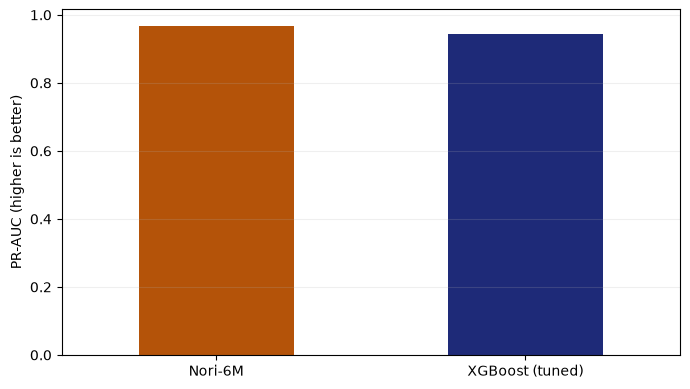

In [8]:
comparison = pd.Series({
    'Nori-6M': nori_metrics['pr_auc'],
    'XGBoost (tuned)': xgb_metrics['pr_auc'],
}, name='PR-AUC')
ylabel = 'PR-AUC (higher is better)'
display(comparison.to_frame().style.format('{:.3f}'))
ax = comparison.plot.bar(color=['#B45309', '#1E2A78'], figsize=(7, 4), rot=0)
ax.set_ylabel(ylabel)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## Adapt the playbook

Replace the sensor summaries with features appropriate to your machines, batteries, vehicles, services, or accounts. The same current/recent/evolution structure can also support problems such as churn prediction by summarizing how an account's usage, clicks, support history, and engagement have changed over time.